In [ ]:
!pip install pm4py

In [18]:
import os
import pandas as pd
import pm4py  # version 2.7.4
from pprint import pprint  # pretty printing
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.algo.evaluation import algorithm as evaluation
from pm4py.objects.conversion.log import converter as stream_converter
from pm4py.objects.log.importer.xes import importer as xes_import
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from pm4py.algo.discovery.alpha_plus import algorithm as alpha_plus_miner
from pm4py.algo.discovery.alpha_pp import algorithm as alpha_pp_miner
from pm4py.algo.discovery.inductive.variants import imf as inductive_miner_infrequent
from pm4py.algo.discovery.ilp import algorithm as ilp_miner
from pm4py.algo.discovery.genetic import algorithm as genetic_miner
from pm4py.algo.discovery.splitminer import algorithm as split_miner
from pm4py.algo.discovery.decision_miner import algorithm as decision_miner
from pm4py.algo.discovery.markov import algorithm as markov_miner



ModuleNotFoundError: No module named 'pm4py.algo.discovery.alpha_plus'

In [8]:
# Carregar o CSV
df = pd.read_csv("caseid_day/processed/event_log.csv")


# Verificar as primeiras linhas
display(df.head(5))

# Renomear colunas para os nomes esperados pelo pm4py
df = df.rename(columns={
    "case_id": "case:concept:name",
    "event_type": "concept:name",
    "timestamp": "time:timestamp",
    "value": "glucose_value"  # atributo adicional (opcional)
})

# Converter colunas principais para string
df["case:concept:name"] = df["case:concept:name"].astype(str)
df["concept:name"] = df["concept:name"].astype(str)

# Converter timestamp para datetime
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

# Ordenar por caso e timestamp (obrigatório!)
df = df.sort_values(["case:concept:name", "time:timestamp"])

# Converter para EventLog
event_log = pm4py.convert_to_event_log(df)

# (Opcional) Também manter como DataFrame para análise
log_df = df.copy()

print("✅ Event log carregado com sucesso!")
print(f"Total de traces (casos): {len(event_log)}")
print(f"Total de eventos: {len(log_df)}")

,case_id,event_type,timestamp,value
0,2023-10-22,Meal,2023-10-22 10:00:00,NaN
1,2023-10-22,PPGR_peak,2023-10-22 10:44:00,9.400000
2,2023-10-22,Meal,2023-10-22 12:00:00,NaN
3,2023-10-22,PPGR_peak,2023-10-22 13:29:00,15.600000
4,2023-10-22,PPGR_recovery,2023-10-22 14:34:00,9.158333


✅ Event log carregado com sucesso!
Total de traces (casos): 85
Total de eventos: 1288


In [9]:
# Estrutura de um trace e de um evento
print("Atributos de um trace (case):")
print(list(event_log[0].attributes.keys()))

print("\nCampos de um evento:")
print(list(event_log[0][0].keys()))

# Atividades únicas
print("\nAtividades únicas:")
print(log_df["concept:name"].unique().tolist())

# Atividades iniciais e finais
print("\nAtividades iniciais:")
print(pm4py.get_start_activities(event_log))

print("\nAtividades finais:")
print(pm4py.get_end_activities(event_log))

Atributos de um trace (case):
['concept:name']

Campos de um evento:
['concept:name', 'time:timestamp', 'glucose_value']

Atividades únicas:
['Meal', 'PPGR_peak', 'PPGR_recovery', 'BolusInsulin']

Atividades iniciais:
{'Meal': 83, 'BolusInsulin': 2}

Atividades finais:
{'PPGR_peak': 30, 'PPGR_recovery': 40, 'BolusInsulin': 15}


In [10]:
# Heuristics Miner (recomendado para logs reais)
h_net, h_im, h_fm = heuristics_miner.apply(event_log)

# Inductive Miner
tree = inductive_miner.apply(event_log)
i_net, i_im, i_fm = pm4py.convert_to_petri_net(tree)

# Alpha Miner (menos robusto, só para comparação)
a_net, a_im, a_fm = alpha_miner.apply(event_log)

# -------------------------------------------------------------
# 1. ILP Miner
# -------------------------------------------------------------
ilp_net, ilp_im, ilp_fm = ilp_miner.apply(event_log)


# -------------------------------------------------------------
# 2. Genetic Miner
# -------------------------------------------------------------
g_net, g_im, g_fm = genetic_miner.apply(event_log)


# -------------------------------------------------------------
# 3. Decision Miner (decision points → rules)
# -------------------------------------------------------------
dm_results = decision_miner.apply(event_log)


# -------------------------------------------------------------
# 4. Markov Model
# -------------------------------------------------------------
markov_model = markov_miner.apply(event_log)


# -------------------------------------------------------------
# 5. Fodina (Heuristics variant)
# -------------------------------------------------------------
fodina_net, fodina_im, fodina_fm = heuristics_miner.apply(
    event_log,
    parameters={"variant": heuristics_miner.Variants.FODINA}
)


# -------------------------------------------------------------
# 6. Split Miner
# -------------------------------------------------------------
sm_net, sm_im, sm_fm = split_miner.apply(event_log)


# -------------------------------------------------------------
# 7. Inductive Miner (Infrequent)
# -------------------------------------------------------------
imf_tree = inductive_miner.apply(event_log, variant=inductive_miner_infrequent.Variants.IMf)
imf_net, imf_im, imf_fm = pm4py.convert_to_petri_net(imf_tree)


# -------------------------------------------------------------
# 8. Alpha+
# -------------------------------------------------------------
ap_net, ap_im, ap_fm = alpha_plus_miner.apply(event_log)


# -------------------------------------------------------------
# 9. Alpha++
# -------------------------------------------------------------
app_net, app_im, app_fm = alpha_pp_miner.apply(event_log)


print("✅ Modelos gerados com sucesso!")

NameError: name 'ilp_miner' is not defined

In [11]:
# Acho que só é preciso correr uma vez, a partir daí está -- (é para a visualização dos gráficos)

#!apt-get update >/dev/null 2>&1
#!apt-get install -y graphviz >/dev/null 2>&1



In [12]:
from pm4py.visualization.petri_net import visualizer as pn_visualizer


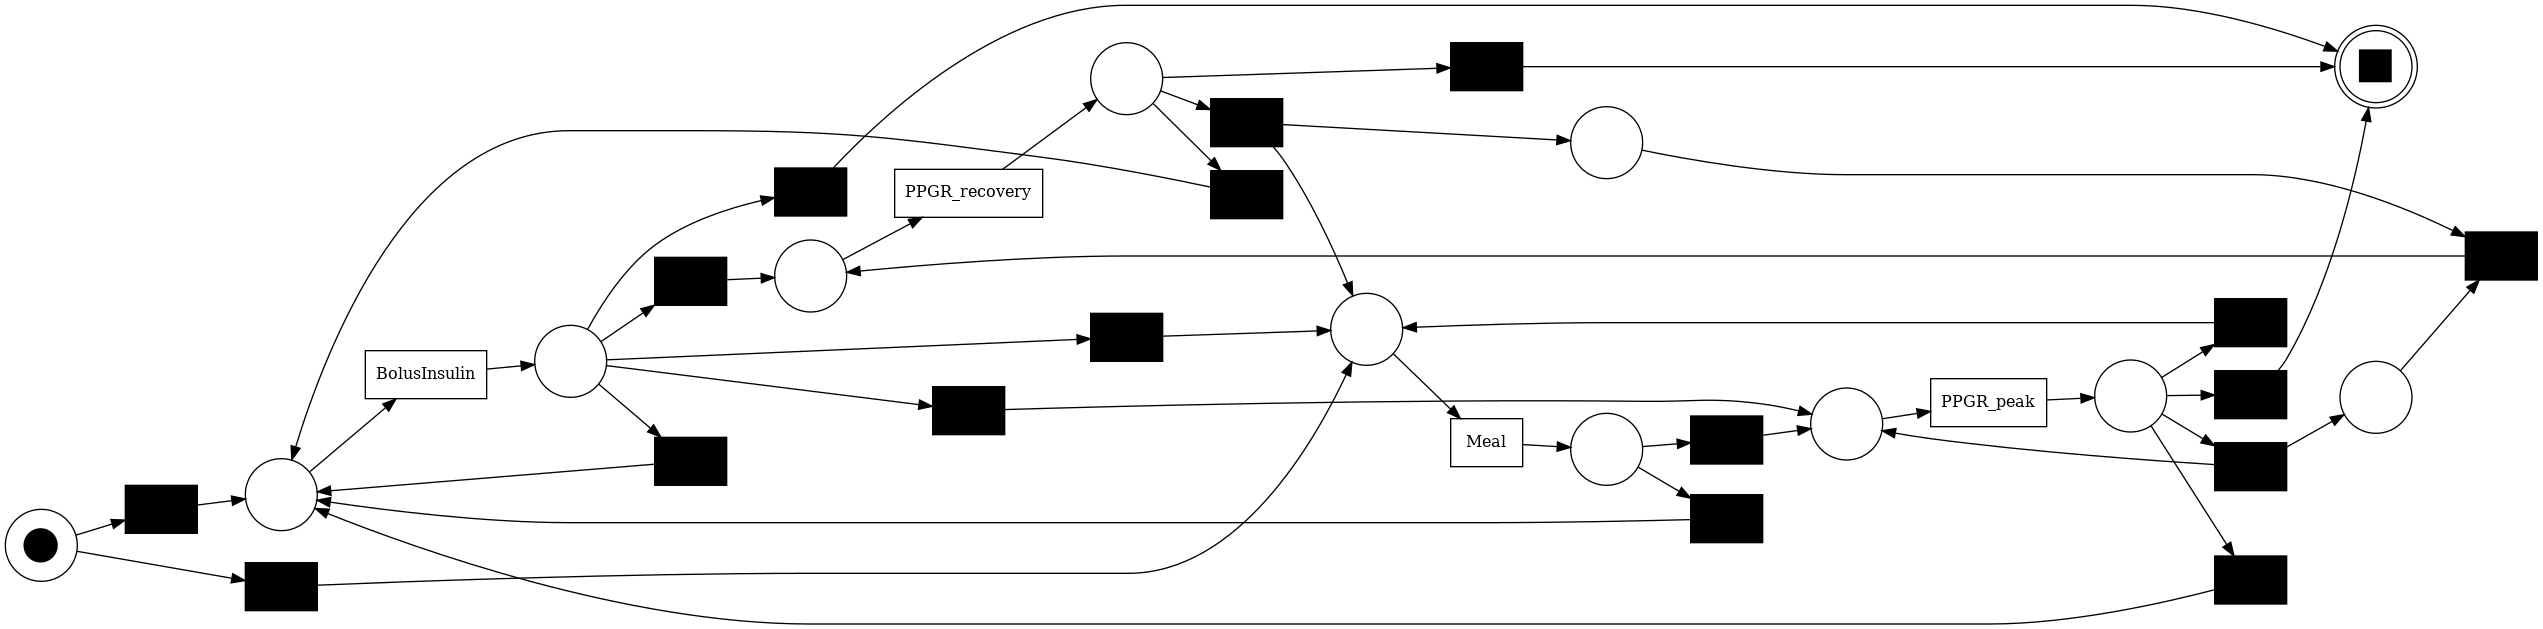

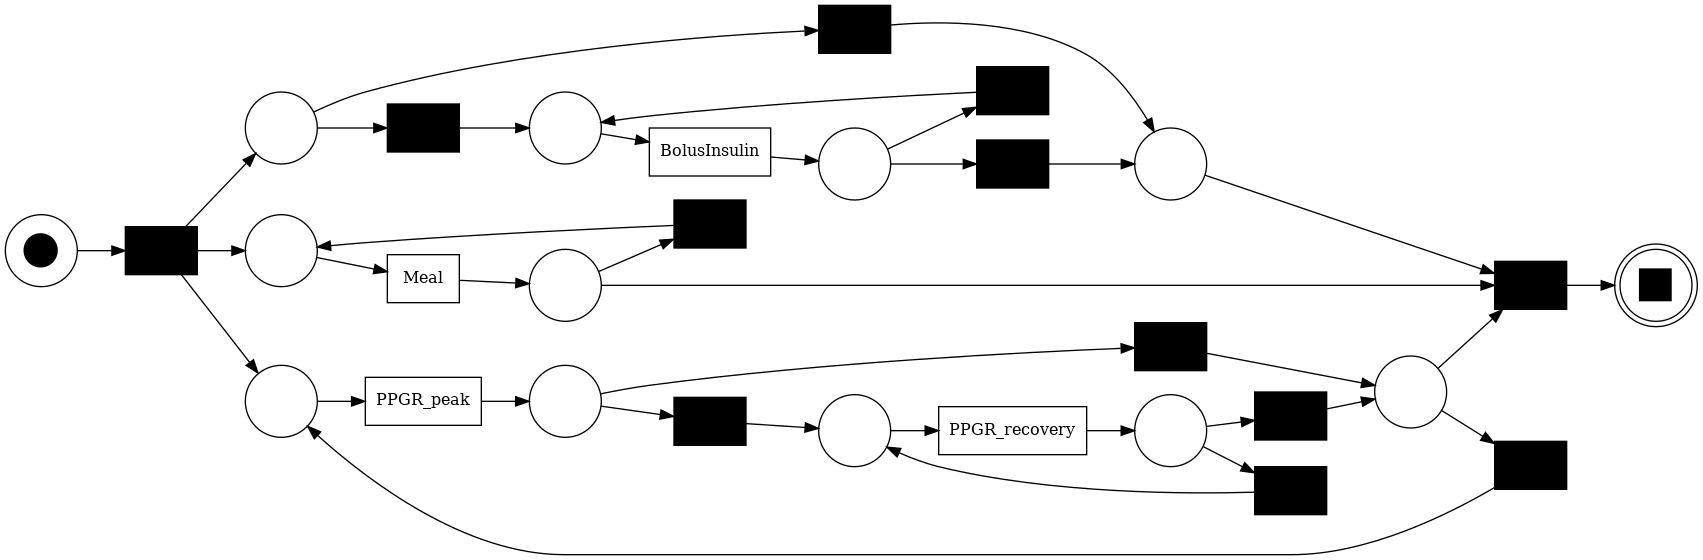

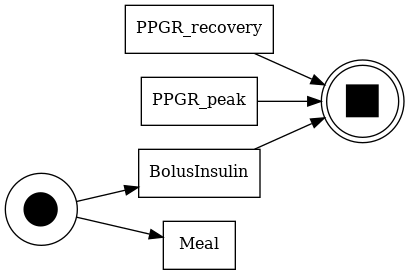

NameError: name 'ilp_net' is not defined

In [13]:

# ===============================
# VISUALIZAÇÃO DOS MODELOS
# ===============================

# --- Heuristics Miner ---
h_gviz = pn_visualizer.apply(h_net, h_im, h_fm)
pn_visualizer.view(h_gviz)
pn_visualizer.save(h_gviz, "data_grafsalterados/graphs/heuristics_miner_petrinet.png")

# --- Inductive Miner ---
i_gviz = pn_visualizer.apply(i_net, i_im, i_fm)
pn_visualizer.view(i_gviz)
pn_visualizer.save(i_gviz, "data_grafsalterados/graphs/inductive_miner_petrinet.png")

# --- Alpha Miner ---
a_gviz = pn_visualizer.apply(a_net, a_im, a_fm)
pn_visualizer.view(a_gviz)
pn_visualizer.save(a_gviz, "data_grafsalterados/graphs/alpha_miner_petrinet.png")


# --- ILP Miner ---
ilp_gviz = pn_visualizer.apply(ilp_net, ilp_im, ilp_fm)
pn_visualizer.view(ilp_gviz)
pn_visualizer.save(ilp_gviz, "data_grafsalterados/graphs/ilp_miner_petrinet.png")


# --- Genetic Miner ---
g_gviz = pn_visualizer.apply(g_net, g_im, g_fm)
pn_visualizer.view(g_gviz)
pn_visualizer.save(g_gviz, "data_grafsalterados/graphs/genetic_miner_petrinet.png")


# --- Fodina Miner ---
fodina_gviz = pn_visualizer.apply(fodina_net, fodina_im, fodina_fm)
pn_visualizer.view(fodina_gviz)
pn_visualizer.save(fodina_gviz, "data_grafsalterados/graphs/fodina_miner_petrinet.png")


# --- Split Miner ---
sm_gviz = pn_visualizer.apply(sm_net, sm_im, sm_fm)
pn_visualizer.view(sm_gviz)
pn_visualizer.save(sm_gviz, "data_grafsalterados/graphs/split_miner_petrinet.png")


# --- Inductive Miner (Infrequent) ---
imf_gviz = pn_visualizer.apply(imf_net, imf_im, imf_fm)
pn_visualizer.view(imf_gviz)
pn_visualizer.save(imf_gviz, "data_grafsalterados/graphs/inductive_miner_infrequent_petrinet.png")


# --- Alpha+ ---
ap_gviz = pn_visualizer.apply(ap_net, ap_im, ap_fm)
pn_visualizer.view(ap_gviz)
pn_visualizer.save(ap_gviz, "data_grafsalterados/graphs/alpha_plus_petrinet.png")


# --- Alpha++ ---
app_gviz = pn_visualizer.apply(app_net, app_im, app_fm)
pn_visualizer.view(app_gviz)
pn_visualizer.save(app_gviz, "data_grafsalterados/graphs/alpha_pp_petrinet.png")




print("Visualizações criadas e guardadas!")


In [14]:
## DECISION MINER E MARKOV NAO GERAM PETRI NET

from graphviz import Digraph
import os

os.makedirs("data_grafsalterados/graphs", exist_ok=True)

# --- Decision Miner visualization (graphviz) ---
def visualize_decision_miner(dm_results, output_path):
    dot = Digraph(comment="Decision Miner Model", format="png")
    dot.attr("node", shape="box", style="rounded,filled", color="lightgray")

    # dm_results é um dict: {activity: rule_list}
    for decision_point, rules in dm_results.items():
        dp_node = f"dp_{decision_point}"
        dot.node(dp_node, f"Decision Point:\n{decision_point}", color="lightblue")

        for i, rule in enumerate(rules):
            rule_node = f"{decision_point}_rule_{i}"
            dot.node(rule_node, f"Rule {i+1}\n{rule}", color="white")
            dot.edge(dp_node, rule_node)

    dot.render(output_path, cleanup=True)


visualize_decision_miner(dm_results, "data_grafsalterados/graphs/decision_miner")



# --- Markov Model visualization ---
def visualize_markov_model(markov_model, output_path):
    dot = Digraph(comment="Markov Model", format="png")
    dot.attr("node", shape="circle", style="filled", color="lightyellow")

    # markov_model é um dict: {(from, to): prob}
    for (src, dst), prob in markov_model.items():
        dot.node(src)
        dot.node(dst)
        dot.edge(src, dst, label=f"{prob:.2f}")

    dot.render(output_path, cleanup=True)


visualize_markov_model(markov_model, "data_grafsalterados/graphs/markov_model")


NameError: name 'dm_results' is not defined

In [15]:
## --- Recall and Comprehensibility ---


def compute_recall(eval_result):
    precision = eval_result["precision"]
    fscore = eval_result["fscore"]

    # evitar divisões por zero
    if precision == 0 or (2 * precision - fscore) == 0:
        return 0.0

    recall = (fscore * precision) / (2 * precision - fscore)
    return recall

def compute_comprehensibility(net):
    num_places = len(net.places)
    num_transitions = len(net.transitions)

    total_elements = num_places + num_transitions

    if total_elements == 0:
        return 0.0

    # quanto menor a estrutura, maior o score
    return 1 / total_elements

In [16]:
# Avaliar Heuristics Miner
eval_h = evaluation.apply(event_log, h_net, h_im, h_fm)
recall_h = compute_recall(eval_h)
eval_h["recall"] = recall_h
compreh_h = compute_comprehensibility(h_net)
eval_h["comprehensibility"] = compreh_h

# Avaliar Inductive Miner
eval_i = evaluation.apply(event_log, i_net, i_im, i_fm)
recall_i = compute_recall(eval_i)
eval_i["recall"] = recall_i
compreh_i = compute_comprehensibility(i_net)
eval_i["comprehensibility"] = compreh_i

# Avaliar Alpha Miner
eval_a = evaluation.apply(event_log, a_net, a_im, a_fm)
recall_a = compute_recall(eval_a)
eval_a["recall"] = recall_a
compreh_a = compute_comprehensibility(a_net)
eval_a["comprehensibility"] = compreh_a


results = {}  # guardar tudo organizado


# -------------------------------------------------------------
# ILP Miner
# -------------------------------------------------------------
eval_ilp = evaluation.apply(event_log, ilp_net, ilp_im, ilp_fm)
eval_ilp["recall"] = compute_recall(eval_ilp)
eval_ilp["comprehensibility"] = compute_comprehensibility(ilp_net)
results["ILP Miner"] = eval_ilp


# -------------------------------------------------------------
# Genetic Miner
# -------------------------------------------------------------
eval_g = evaluation.apply(event_log, g_net, g_im, g_fm)
eval_g["recall"] = compute_recall(eval_g)
eval_g["comprehensibility"] = compute_comprehensibility(g_net)
results["Genetic Miner"] = eval_g


# -------------------------------------------------------------
# Fodina
# -------------------------------------------------------------
eval_fodina = evaluation.apply(event_log, fodina_net, fodina_im, fodina_fm)
eval_fodina["recall"] = compute_recall(eval_fodina)
eval_fodina["comprehensibility"] = compute_comprehensibility(fodina_net)
results["Fodina"] = eval_fodina


# -------------------------------------------------------------
# Split Miner
# -------------------------------------------------------------
eval_sm = evaluation.apply(event_log, sm_net, sm_im, sm_fm)
eval_sm["recall"] = compute_recall(eval_sm)
eval_sm["comprehensibility"] = compute_comprehensibility(sm_net)
results["Split Miner"] = eval_sm


# -------------------------------------------------------------
# Inductive Miner Infrequent
# -------------------------------------------------------------
eval_imf = evaluation.apply(event_log, imf_net, imf_im, imf_fm)
eval_imf["recall"] = compute_recall(eval_imf)
eval_imf["comprehensibility"] = compute_comprehensibility(imf_net)
results["Inductive Miner (Infrequent)"] = eval_imf


# -------------------------------------------------------------
# Alpha+
# -------------------------------------------------------------
eval_ap = evaluation.apply(event_log, ap_net, ap_im, ap_fm)
eval_ap["recall"] = compute_recall(eval_ap)
eval_ap["comprehensibility"] = compute_comprehensibility(ap_net)
results["Alpha+"] = eval_ap


# -------------------------------------------------------------
# Alpha++
# -------------------------------------------------------------
eval_app = evaluation.apply(event_log, app_net, app_im, app_fm)
eval_app["recall"] = compute_recall(eval_app)
eval_app["comprehensibility"] = compute_comprehensibility(app_net)
results["Alpha++"] = eval_app



print("Avaliação - Heuristics Miner:")
pprint(eval_h)

print("\nAvaliação - Inductive Miner:")
pprint(eval_i)

print("\nAvaliação - Alpha Miner:")
pprint(eval_a)

# -------------------------------------------------------------
# PRINT FINAL
# -------------------------------------------------------------
print("\n============== RESULTADOS DE AVALIAÇÃO ==============\n")
for miner_name, data in results.items():
    print(f"\n--- {miner_name} ---")
    pprint(data)


replaying log with TBR, completed traces ::   0%|          | 0/83 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/701 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/83 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/701 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/83 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/701 [00:00<?, ?it/s]

NameError: name 'ilp_net' is not defined

In [3]:
## AVALIAÇÃO MARKOV E DECISION MINER

def evaluate_decision_miner(event_log, dm_results):
    
    total_decision_points = 0
    correct_predictions = 0
    covered_points = 0

    for trace in event_log:
        events = [e["concept:name"] for e in trace]

        for i in range(len(events) - 1):
            curr = events[i]
            next_event = events[i + 1]
            total_decision_points += 1

            # se houver regras para este ponto
            if curr in dm_results:
                covered_points += 1
                rules = dm_results[curr]

                predicted = False
                for rule in rules:
                    # regra válida se o próximo evento estiver listado
                    if next_event in str(rule):
                        correct_predictions += 1
                        predicted = True
                        break

    accuracy = correct_predictions / covered_points if covered_points > 0 else 0
    coverage = covered_points / total_decision_points if total_decision_points > 0 else 0
    
    return {
        "accuracy": accuracy,
        "coverage": coverage,
        "support": covered_points,
        "total": total_decision_points
    }


decision_eval = evaluate_decision_miner(event_log, dm_results)

print("Avaliação Decision Miner:")
print(decision_eval)


import math

def evaluate_markov(event_log, markov_model):
    log_likelihood = 0
    transition_count = 0

    for trace in event_log:
        events = [e["concept:name"] for e in trace]
        for i in range(len(events) - 1):
            src = events[i]
            dst = events[i+1]

            prob = markov_model.get((src, dst), 1e-10)  # evitar log(0)

            log_likelihood += math.log(prob)
            transition_count += 1

    avg_log_likelihood = log_likelihood / transition_count
    cross_entropy = -avg_log_likelihood
    perplexity = math.exp(cross_entropy)

    return {
        "avg_log_likelihood": avg_log_likelihood,
        "cross_entropy": cross_entropy,
        "perplexity": perplexity
    }


markov_eval = evaluate_markov(event_log, markov_model)

print("Avaliação Markov Model:")
print(markov_eval)



NameError: name 'event_log' is not defined

In [4]:
# Verificar quais traces se encaixam perfeitamente no modelo (Heuristics)
print("\n Replaying log with TBR - Heuristics Miner:")
replayed_h = token_replay.apply(event_log, h_net, h_im, h_fm)

# Contar traces que NÃO se encaixam
not_fit_h = sum(1 for trace in replayed_h if not trace['trace_is_fit'])
total_h = len(replayed_h)

print(f"Traces que NÃO se ajustam ao modelo: {not_fit_h} de {total_h}")
print(f"Taxa de conformidade: {(1 - not_fit_h/total_h)*100:.1f}%")

print("\n Replaying log with TBR - Inductive Miner:")
replayed_i = token_replay.apply(event_log, i_net, i_im, i_fm)

# Contar traces que NÃO se encaixam
not_fit_i = sum(1 for trace in replayed_i if not trace['trace_is_fit'])
total_i = len(replayed_i)

print(f"Traces que NÃO se ajustam ao modelo: {not_fit_i} de {total_i}")
print(f"Taxa de conformidade: {(1 - not_fit_i/total_i)*100:.1f}%")

print("\n Replaying log with TBR - Alpha Miner:")
replayed_a = token_replay.apply(event_log, a_net, a_im, a_fm)

# Contar traces que NÃO se encaixam
not_fit_a = sum(1 for trace in replayed_a if not trace['trace_is_fit'])
total_a = len(replayed_a)

print(f"Traces que NÃO se ajustam ao modelo: {not_fit_a} de {total_a}")
print(f"Taxa de conformidade: {(1 - not_fit_a/total_a)*100:.1f}%")


 Replaying log with TBR - Heuristics Miner:


NameError: name 'token_replay' is not defined

In [186]:
# Tempo médio entre "Meal" e "PPGR_peak"
meal_to_peak = log_df[log_df["concept:name"] == "PPGR_peak"].copy()
meal_to_peak = meal_to_peak.merge(
    log_df[log_df["concept:name"] == "Meal"][["case:concept:name", "time:timestamp"]].rename(
        columns={"time:timestamp": "meal_time"}
    ),
    on="case:concept:name",
    how="inner"
)

meal_to_peak["time_to_peak"] = (
    meal_to_peak["time:timestamp"] - meal_to_peak["meal_time"]
).dt.total_seconds() / 60  # em minutos

print(f"\nTempo médio para atingir o pico: {meal_to_peak['time_to_peak'].mean():.1f} minutos")

# Valor médio do pico
peak_values = log_df[log_df["concept:name"] == "PPGR_peak"]["glucose_value"]
print(f"Valor médio do pico: {peak_values.mean():.2f} mmol/L")


Tempo médio para atingir o pico: 68.1 minutos
Valor médio do pico: 10.65 mmol/L
